# 05 — Inventory Cost Calculation

## Objective

The goal of this notebook is to evaluate how different forecasting strategies translate into inventory decisions and to identify the strategy that minimizes total business cost.

---

## From Forecasting to Inventory Decisions

In this analysis, predicted demand from each model is interpreted as the inventory level Walmart chooses to stock for a given category, store, and date.

---

## Cost Framework

Inventory cost is composed of two components:
- **Stockout Cost**: Cost incurred when demand exceeds available inventory
- **Overstock Cost**: Cost incurred when inventory exceeds demand

Because stockouts often lead to lost sales and customer dissatisfaction, they are typically more expensive than overstock.

---

## Evaluation Approach

We compare multiple forecasting strategies—including standard models and cost-aware adjustments—by calculating their resulting inventory costs. Each strategy is evaluated based on its ability to balance stockouts and overstock under different cost assumptions.

---

## Key Question

**Given different discount conditions, what inventory level should Walmart stock to minimize total cost from stockouts and overstock?**

We answer this by using model predictions (which incorporate discount effects) as inventory decisions and evaluating their resulting cost.

---
## 1. Import Libraries and Load Prediction Outputs


In [ ]:
# ── Uncomment below when running on Google Colab ──
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

# Paths relative to the notebooks/ folder
DATA_DIR = "../data/output/"
FIG_DIR = "../figures"

df = pd.read_csv(DATA_DIR + "predictions_with_quantile.csv", parse_dates=["date"])

print(df.shape)
df.head()

(1680, 11)


,id,cat_id,store_id,state_id,date,sales,pred_naive,pred_ridge,pred_xgb,pred_xgb_adj,pred_qxgb
0,FOODS_CA_1,FOODS,CA_1,CA,2016-02-29,16,12.0,15.921513,15.352761,23.577976,20.046751
1,FOODS_CA_1,FOODS,CA_1,CA,2016-03-01,13,21.0,16.612550,16.550821,24.776035,23.097424
2,FOODS_CA_1,FOODS,CA_1,CA,2016-03-02,18,13.0,15.649758,15.886890,24.112104,21.815641
3,FOODS_CA_1,FOODS,CA_1,CA,2016-03-03,20,12.0,16.505770,16.510662,24.735876,22.012297
4,FOODS_CA_1,FOODS,CA_1,CA,2016-03-04,10,21.0,17.298908,18.016567,26.241781,24.307280


---
## 2. Category-Specific Inventory Cost Assumptions

Inventory cost is not the same across product categories. We assign different stockout and overstock costs based on how costly it is for Walmart to understock or overstock each category.

- **FOODS:** Stockouts are highly costly because food items are often essential and frequently purchased.
- **HOUSEHOLD:** Stockouts are moderately costly because these items are useful but less urgent than food.
- **HOBBIES:** Stockout and overstock costs are treated equally because these products are more discretionary.

These assumptions allow the inventory cost calculation to better reflect realistic business priorities.

In [ ]:
# Category-specific cost assumptions
cat_costs = {
    "FOODS": {"cu": 5, "co": 1},
    "HOUSEHOLD": {"cu": 2, "co": 1},
    "HOBBIES": {"cu": 1, "co": 1},
}

---
##3. Check Prediction Column

In [ ]:
prediction_cols = [
    "pred_naive",
    "pred_ridge",
    "pred_xgb",
    "pred_xgb_adj",
    "pred_qxgb"
]

# keep only prediction columns that actually exist
prediction_cols = [col for col in prediction_cols if col in df.columns]

print("Prediction columns:", prediction_cols)
print("Categories:", df["cat_id"].unique())

Prediction columns: ['pred_naive', 'pred_ridge', 'pred_xgb', 'pred_xgb_adj', 'pred_qxgb']
Categories: ['FOODS' 'HOBBIES' 'HOUSEHOLD']


---
## 4. Inventory Cost Function

For each strategy, predicted demand is treated as the inventory quantity Walmart stocks. If actual demand exceeds predicted inventory, the difference becomes stockout units. If predicted inventory exceeds actual demand, the difference becomes overstock units.

The cost is calculated using category-specific stockout and overstock costs.

In [ ]:
def calculate_category_inventory_cost(data, prediction_col, cat_costs):
    """
    Calculate inventory cost using category-specific stockout and overstock costs.
    """
    result = data.copy()

    # assign category-specific costs
    result["cu"] = result["cat_id"].map(lambda x: cat_costs[x]["cu"])
    result["co"] = result["cat_id"].map(lambda x: cat_costs[x]["co"])

    actual = result["sales"]
    inventory = result[prediction_col].clip(lower=0)

    result["stockout_units"] = (actual - inventory).clip(lower=0)
    result["overstock_units"] = (inventory - actual).clip(lower=0)

    result["stockout_cost"] = result["stockout_units"] * result["cu"]
    result["overstock_cost"] = result["overstock_units"] * result["co"]
    result["total_cost"] = result["stockout_cost"] + result["overstock_cost"]

    return result

---
##5. Evaluate All Strategies

In [ ]:
results = []

for col in prediction_cols:
    cost_df = calculate_category_inventory_cost(df, col, cat_costs)

    results.append({
        "Strategy": col,
        "Avg Stockout Units": cost_df["stockout_units"].mean(),
        "Avg Overstock Units": cost_df["overstock_units"].mean(),
        "Avg Stockout Cost": cost_df["stockout_cost"].mean(),
        "Avg Overstock Cost": cost_df["overstock_cost"].mean(),
        "Mean Inventory Cost": cost_df["total_cost"].mean(),
        "Total Inventory Cost": cost_df["total_cost"].sum()
    })

inventory_results = pd.DataFrame(results).sort_values("Mean Inventory Cost")

inventory_results

,Strategy,Avg Stockout Units,Avg Overstock Units,Avg Stockout Cost,Avg Overstock Cost,Mean Inventory Cost,Total Inventory Cost
4,pred_qxgb,1.107337,3.664731,2.937022,3.664731,6.601753,11090.944762
3,pred_xgb_adj,0.979006,4.080186,2.758194,4.080186,6.838380,11488.477764
2,pred_xgb,2.021019,1.879302,7.360010,1.879302,9.239312,15522.044053
1,pred_ridge,2.162277,1.944588,7.718578,1.944588,9.663166,16234.118861
0,pred_naive,2.750595,2.620238,9.807143,2.620238,12.427381,20878.000000


In [ ]:
strategy_name_map = {
    "pred_naive": "Seasonal Naive",
    "pred_ridge": "Ridge Regression",
    "pred_xgb": "XGBoost",
    "pred_xgb_adj": "XGBoost + Adjustment",
    "pred_qxgb": "Quantile XGBoost"
}

inventory_results["Strategy Name"] = (
    inventory_results["Strategy"]
    .map(strategy_name_map)
    .fillna(inventory_results["Strategy"])
)

inventory_results = inventory_results[
    [
        "Strategy Name",
        "Avg Stockout Units",
        "Avg Overstock Units",
        "Avg Stockout Cost",
        "Avg Overstock Cost",
        "Mean Inventory Cost",
        "Total Inventory Cost"
    ]
]

inventory_results

,Strategy Name,Avg Stockout Units,Avg Overstock Units,Avg Stockout Cost,Avg Overstock Cost,Mean Inventory Cost,Total Inventory Cost
4,Quantile XGBoost,1.107337,3.664731,2.937022,3.664731,6.601753,11090.944762
3,XGBoost + Adjustment,0.979006,4.080186,2.758194,4.080186,6.838380,11488.477764
2,XGBoost,2.021019,1.879302,7.360010,1.879302,9.239312,15522.044053
1,Ridge Regression,2.162277,1.944588,7.718578,1.944588,9.663166,16234.118861
0,Seasonal Naive,2.750595,2.620238,9.807143,2.620238,12.427381,20878.000000


---
##6. Visualize Mean Inventory Cost

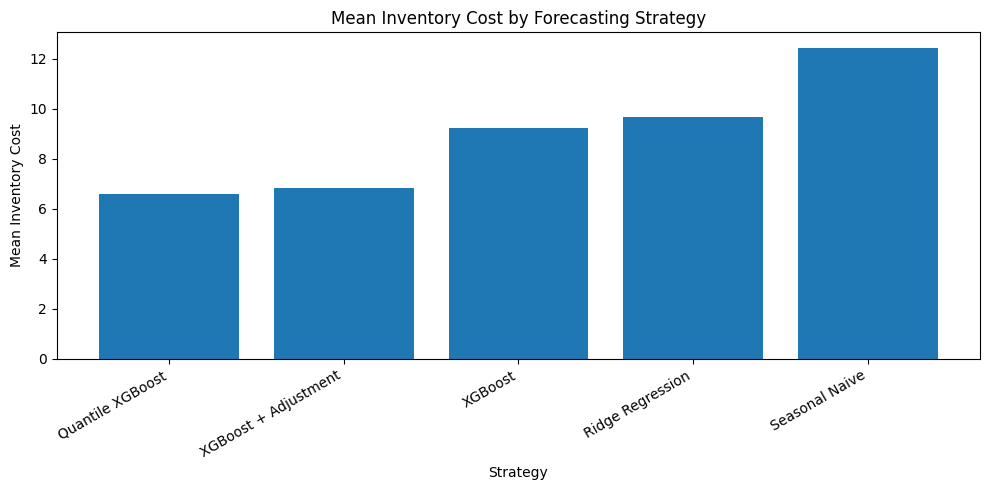

Saved: figures/mean_inventory_cost.png


In [ ]:
plot_df = inventory_results.sort_values("Mean Inventory Cost")

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(plot_df["Strategy Name"], plot_df["Mean Inventory Cost"])
ax.set_title("Mean Inventory Cost by Forecasting Strategy")
ax.set_xlabel("Strategy")
ax.set_ylabel("Mean Inventory Cost")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/mean_inventory_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/mean_inventory_cost.png')

This visualization shows that inventory decisions should not be evaluated based on prediction accuracy alone. The best-performing strategy is the one that minimizes total cost, not necessarily the one with the lowest forecast error.

---
##7. Demand, Pricing, and Inventory Decision Dynamics

Selected sample: HOUSEHOLD - WI_3
Max absolute price change: 15.51%


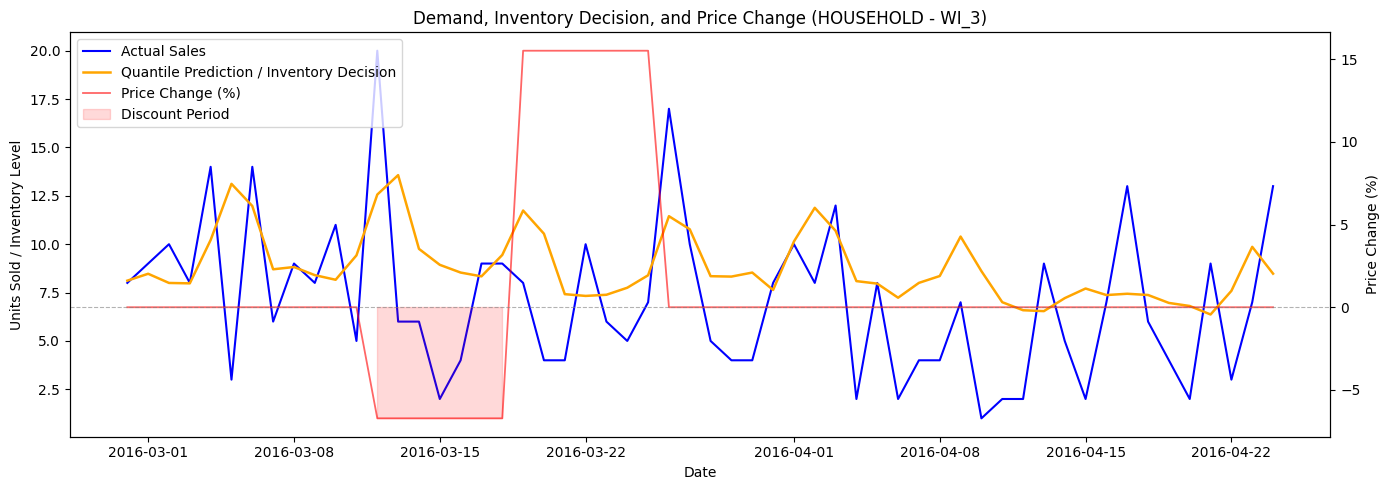

Saved: figures/demand_pricing_inventory_dynamics.png


,date,cat_id,store_id,sales,pred_qxgb,price_change_pct
0,2016-02-29,FOODS,CA_1,16,20.046751,0.0
1,2016-03-01,FOODS,CA_1,13,23.097424,0.0
2,2016-03-02,FOODS,CA_1,18,21.815641,0.0
3,2016-03-03,FOODS,CA_1,20,22.012297,0.0
4,2016-03-04,FOODS,CA_1,10,24.307280,0.0


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Merge price_change_pct back into predictions data ────────────────────────
features = pd.read_csv(DATA_DIR + "features_holdout.csv", parse_dates=["date"])

# Drop existing price_change_pct columns if cell was run multiple times
df = df.drop(columns=[col for col in df.columns if "price_change_pct" in col], errors="ignore")

df = df.merge(
    features[["date", "cat_id", "store_id", "price_change_pct"]],
    on=["date", "cat_id", "store_id"],
    how="left"
)

# ── Pick a category-store combination with visible price changes ─────────────
# Prefer groups with the largest absolute price changes
price_change_summary = (
    df.assign(abs_price_change=df["price_change_pct"].fillna(0).abs())
    .groupby(["cat_id", "store_id"])["abs_price_change"]
    .max()
    .reset_index()
    .sort_values("abs_price_change", ascending=False)
)

sample_key = price_change_summary.iloc[0]
cat = sample_key["cat_id"]
store = sample_key["store_id"]

print(f"Selected sample: {cat} - {store}")
print(f"Max absolute price change: {sample_key['abs_price_change']:.2%}")

s = df[(df["cat_id"] == cat) & (df["store_id"] == store)].copy()
s = s.sort_values("date")

# Convert price change to percent for easier reading
s["price_change_pct_display"] = s["price_change_pct"] * 100

# ── Multi-axis plot ─────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Sales + inventory decision
ax1.plot(
    s["date"], s["sales"],
    label="Actual Sales",
    color="blue",
    linewidth=1.5
)

ax1.plot(
    s["date"], s["pred_qxgb"],
    label="Quantile Prediction / Inventory Decision",
    color="orange",
    linewidth=1.8
)

ax1.set_ylabel("Units Sold / Inventory Level")
ax1.set_xlabel("Date")

# Price change on right axis
ax2 = ax1.twinx()

ax2.plot(
    s["date"], s["price_change_pct_display"],
    label="Price Change (%)",
    color="red",
    alpha=0.6,
    linewidth=1.3
)

# Highlight meaningful discount periods
ax2.fill_between(
    s["date"],
    s["price_change_pct_display"],
    0,
    where=s["price_change_pct"] < -0.02,
    color="red",
    alpha=0.15,
    label="Discount Period"
)

ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.set_ylabel("Price Change (%)")

# Title and legend
ax1.set_title(f"Demand, Inventory Decision, and Price Change ({cat} - {store})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/demand_pricing_inventory_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/demand_pricing_inventory_dynamics.png')

# Preview merged data
df[["date", "cat_id", "store_id", "sales", "pred_qxgb", "price_change_pct"]].head()

This chart shows how discounts influence demand and inventory decisions. During discount periods, we observe spikes in demand, and the quantile model responds by increasing inventory levels to reduce stockouts.

---
##8. Stockout vs Overstock Breakdown

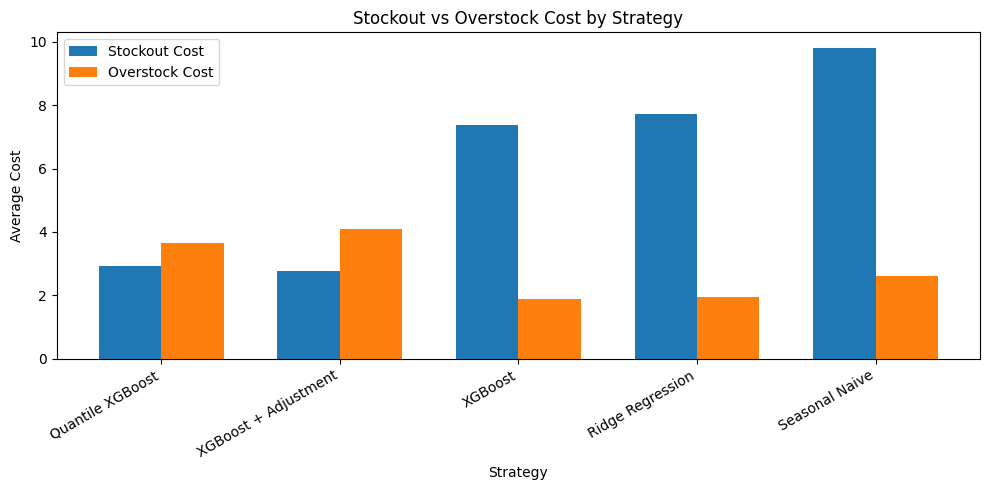

Saved: figures/stockout_vs_overstock.png


In [ ]:
breakdown_df = inventory_results.sort_values("Mean Inventory Cost")

x = np.arange(len(breakdown_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width/2,
    breakdown_df["Avg Stockout Cost"],
    width,
    label="Stockout Cost"
)

ax.bar(
    x + width/2,
    breakdown_df["Avg Overstock Cost"],
    width,
    label="Overstock Cost"
)

ax.set_title("Stockout vs Overstock Cost by Strategy")
ax.set_xlabel("Strategy")
ax.set_ylabel("Average Cost")
ax.set_xticks(x)
ax.set_xticklabels(breakdown_df["Strategy Name"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/stockout_vs_overstock.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/stockout_vs_overstock.png')

This breakdown helps explain why certain strategies perform better. Strategies with high stockout costs indicate underprediction, while strategies with higher overstock costs reflect more conservative inventory decisions.

---
##9. Cost by Category

In [ ]:
category_results = []

for cat in df["cat_id"].unique():
    sub = df[df["cat_id"] == cat].copy()

    for col in prediction_cols:
        cost_df = calculate_category_inventory_cost(sub, col, cat_costs)

        category_results.append({
            "Category": cat,
            "Strategy": strategy_name_map.get(col, col),
            "Mean Inventory Cost": cost_df["total_cost"].mean(),
            "Total Inventory Cost": cost_df["total_cost"].sum(),
            "Avg Stockout Cost": cost_df["stockout_cost"].mean(),
            "Avg Overstock Cost": cost_df["overstock_cost"].mean()
        })

category_cost_df = pd.DataFrame(category_results)

category_cost_df.head()

,Category,Strategy,Mean Inventory Cost,Total Inventory Cost,Avg Stockout Cost,Avg Overstock Cost
0,FOODS,Seasonal Naive,28.166071,15773.000000,23.839286,4.326786
1,FOODS,Ridge Regression,22.020420,12331.435092,18.866691,3.153729
2,FOODS,XGBoost,21.082779,11806.356191,18.087287,2.995492
3,FOODS,XGBoost + Adjustment,14.201259,7952.704767,5.498342,8.702917
4,FOODS,Quantile XGBoost,13.587500,7609.000076,5.591799,7.995702


In [ ]:
category_pivot = category_cost_df.pivot(
    index="Strategy",
    columns="Category",
    values="Mean Inventory Cost"
)

category_pivot

Category,FOODS,HOBBIES,HOUSEHOLD
Strategy,,,
Quantile XGBoost,13.587500,1.914361,4.303398
Ridge Regression,22.020420,2.240885,4.728193
Seasonal Naive,28.166071,2.767857,6.348214
XGBoost,21.082779,2.020400,4.614757
XGBoost + Adjustment,14.201259,2.020400,4.293480


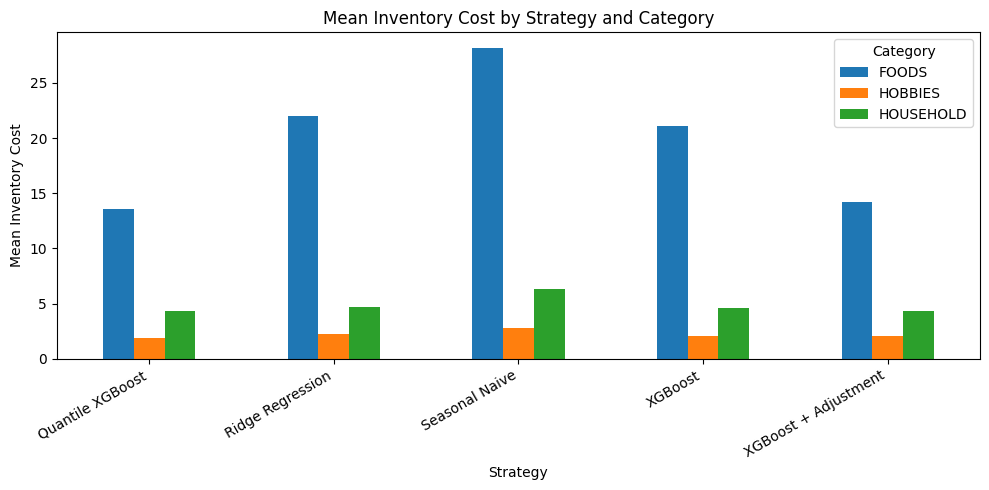

Saved: figures/cost_by_category.png


In [ ]:
category_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Mean Inventory Cost by Strategy and Category")
plt.xlabel("Strategy")
plt.ylabel("Mean Inventory Cost")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cost_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cost_by_category.png')

This category-level analysis shows whether the same inventory strategy works best across all product categories. Since FOODS has a higher stockout penalty, cost-aware strategies may perform especially well in that category.

---
#10. Identify Best Strategy Overall and by Category

In [ ]:
best_overall = inventory_results.sort_values("Mean Inventory Cost").iloc[0]

print("Best overall strategy:", best_overall["Strategy Name"])
print("Mean inventory cost:", round(best_overall["Mean Inventory Cost"], 3))
print("Total inventory cost:", round(best_overall["Total Inventory Cost"], 3))

Best overall strategy: Quantile XGBoost
Mean inventory cost: 6.602
Total inventory cost: 11090.945


In [ ]:
best_by_category = (
    category_cost_df
    .sort_values("Mean Inventory Cost")
    .groupby("Category")
    .first()
    .reset_index()
)

best_by_category

,Category,Strategy,Mean Inventory Cost,Total Inventory Cost,Avg Stockout Cost,Avg Overstock Cost
0,FOODS,Quantile XGBoost,13.587500,7609.000076,5.591799,7.995702
1,HOBBIES,Quantile XGBoost,1.914361,1072.041978,1.188034,0.726326
2,HOUSEHOLD,XGBoost + Adjustment,4.293480,2404.348885,1.877782,2.415698


This result suggests that inventory strategies may benefit from being tailored by category rather than applying a single policy across all products.

---
##11. Save Outputs

In [ ]:
inventory_results.to_csv(DATA_DIR + "inventory_cost_results.csv", index=False)
category_cost_df.to_csv(DATA_DIR + "inventory_cost_by_category.csv", index=False)
best_by_category.to_csv(DATA_DIR + "best_strategy_by_category.csv", index=False)

print("Saved inventory cost results.")

Saved inventory cost results.


## Final Interpretation

This notebook evaluates forecasting strategies as inventory decision rules under different demand conditions driven by discounts. Rather than focusing solely on prediction accuracy, we assess each strategy based on the total inventory cost it produces, including both stockout and overstock costs.

Discounts play a key role in this analysis by increasing demand variability and creating spikes in sales. These demand changes are captured by the forecasting models and directly influence inventory decisions. As a result, the effectiveness of each strategy depends on how well it adapts to these discount-driven demand patterns.

###Results
The results show that the most accurate forecasting model does not necessarily lead to the lowest inventory cost. While **XGBoost** performs best in terms of RMSE and MAE, it does not minimize total cost because it can underestimate demand during high-demand periods, leading to costly stockouts.

Cost-aware strategies, particularly Quantile XGBoost, perform **best** in minimizing total inventory cost. These strategies intentionally produce more conservative (higher) demand estimates, which reduce stockouts at the expense of slightly increased overstock. Given that stockouts are more expensive than overstock—especially in categories such as FOODS—this tradeoff leads to lower overall cost.

> The category-level analysis further supports this conclusion. In categories with high stockout penalties, such as FOODS, conservative strategies provide significant cost savings. In contrast, categories like HOBBIES, where stockout and overstock costs are more balanced, show smaller differences across strategies. This highlights the importance of aligning inventory decisions with category-specific cost structures.

##Conclusion
Overall, the optimal inventory decision is not a fixed quantity, but a strategy as an inventory decision rule. The best approach is for Walmart to stock inventory based on predictions from a cost-aware forecasting model, such as Quantile XGBoost. This allows inventory levels to dynamically adjust to discount-driven demand while minimizing total cost.